In [99]:
!rm -rf * # For reset file storage on colab for rerunning

In [100]:
from google.colab import files
uploaded = files.upload()

Saving FPT-VNINDEX-Dividend.csv to FPT-VNINDEX-Dividend.csv
Saving FPT-VNINDEX-History.csv to FPT-VNINDEX-History.csv
Saving FPT-VNINDEX-Industry.csv to FPT-VNINDEX-Industry.csv
Saving MBB-VNINDEX-Dividend.csv to MBB-VNINDEX-Dividend.csv
Saving MBB-VNINDEX-History.csv to MBB-VNINDEX-History.csv
Saving MBB-VNINDEX-Industry.csv to MBB-VNINDEX-Industry.csv
Saving NLG-VNINDEX-Dividend.csv to NLG-VNINDEX-Dividend.csv
Saving NLG-VNINDEX-History.csv to NLG-VNINDEX-History.csv
Saving NLG-VNINDEX-Industry.csv to NLG-VNINDEX-Industry.csv
Saving VCB-VNINDEX-Dividend.csv to VCB-VNINDEX-Dividend.csv
Saving VCB-VNINDEX-History.csv to VCB-VNINDEX-History.csv
Saving VCB-VNINDEX-Industry.csv to VCB-VNINDEX-Industry.csv
Saving VHM-VNINDEX-Dividend.csv to VHM-VNINDEX-Dividend.csv
Saving VHM-VNINDEX-History.csv to VHM-VNINDEX-History.csv
Saving VHM-VNINDEX-Industry.csv to VHM-VNINDEX-Industry.csv
Saving VNM-VNINDEX-Dividend.csv to VNM-VNINDEX-Dividend.csv
Saving VNM-VNINDEX-History.csv to VNM-VNINDEX-Hist

In [101]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dense, Dropout,
                                     GlobalAveragePooling1D, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

In [102]:
# Config
TICKERS      = ['VNM', 'MBB', 'VHM', 'VCB', 'VRE', 'NLG', 'FPT']
FEATURES     = ['Open', 'High', 'Low', 'Close', 'Volume']
NUM_FEATURES = len(FEATURES)
WINDOW_SIZE  = 20
FUTURE_N     = 7 # predict return after 7 days
EPOCHS_CV    = 15
EPOCHS_FINAL = 50
BATCH_SIZE   = 32
N_SPLITS     = 5
W_CNN        = 0.70  # CNN return score weight
W_DIV        = 0.30  # dividend score weight

In [103]:
# Load Data
def load_history(ticker):
    df = pd.read_csv(f'{ticker}-VNINDEX-History.csv')
    df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)],
            inplace=True, errors='ignore')
    df['TradingDate'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('TradingDate').reset_index(drop=True)
    df = df.dropna(subset=FEATURES)
    return df


def load_dividend(ticker):
    df = pd.read_csv(f'{ticker}-VNINDEX-Dividend.csv')
    df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)],
            inplace=True, errors='ignore')
    annual = df.groupby('cashYear')['cashDividendPercentage'].sum()
    return float(annual.mean())

history_data  = {t: load_history(t)  for t in TICKERS}
dividend_data = {t: load_dividend(t) for t in TICKERS}

for t in TICKERS:
    df = history_data[t]
    print(f'{t:4s}: {len(df):4d} rows')

VNM : 4264 rows
MBB : 2827 rows
VHM : 1198 rows
VCB : 3413 rows
VRE : 1327 rows
NLG : 2470 rows
FPT : 4038 rows


In [104]:
# Create (X, y) for regression
def make_windows(df, window_size, future_n):
    close = df['Close'].values
    feat  = df[FEATURES].values
    X, y  = [], []
    for i in range(len(df) - window_size - future_n):
        t_now    = i + window_size - 1
        t_future = t_now + future_n
        ret = (close[t_future] - close[t_now]) / (close[t_now] + 1e-8)
        X.append(feat[i : i + window_size])
        y.append(ret)
    return np.array(X), np.array(y)

In [105]:
# CNN architecture
def build_model(window_size, num_features):
    model = Sequential([
        Conv1D(32, 3, activation='relu', padding='same',
               input_shape=(window_size, num_features)),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),

        Conv1D(64, 3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

In [106]:
# Cross-validation
def run_cv(X_train, y_train, window_size, num_features, n_splits=5):
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    losses = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_vc = X_train[tr_idx], X_train[val_idx]
        y_tr, y_vc = y_train[tr_idx], y_train[val_idx]

        sc = MinMaxScaler()
        X_tr_n = sc.fit_transform(
            X_tr.reshape(-1, num_features)).reshape(X_tr.shape)
        X_vc_n = sc.transform(
            X_vc.reshape(-1, num_features)).reshape(X_vc.shape)

        ym, ys = y_tr.mean(), y_tr.std() + 1e-8
        m = build_model(window_size, num_features)
        es = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)
        m.fit(X_tr_n, (y_tr - ym) / ys,
              validation_data=(X_vc_n, (y_vc - ym) / ys),
              epochs=EPOCHS_CV, batch_size=BATCH_SIZE,
              callbacks=[es], verbose=0)

        loss = m.evaluate(X_vc_n, (y_vc - ym) / ys, verbose=0)[0]
        losses.append(loss)

    return float(np.mean(losses)), float(np.std(losses))

In [107]:
def train_one_company(ticker, df):
    """
    Full pipeline:
      1. Make windows
      2. Split 64/16/20 (no shuffle)
      3. Normalize (fit train only)
      4. TimeSeriesSplit CV
      5. Train final model
      6. Predict on test → CNN Return Score
    """
    X, y = make_windows(df, WINDOW_SIZE, FUTURE_N)

    # Split
    n = len(X)
    test_size = int(n * 0.20)
    val_size  = int((n - test_size) * 0.20)
    c1 = n - test_size - val_size
    c2 = n - test_size

    X_train, X_val, X_test = X[:c1], X[c1:c2], X[c2:]
    y_train, y_val, y_test = y[:c1], y[c1:c2], y[c2:]

    # Normalize X
    sc_X = MinMaxScaler()
    X_train_n = sc_X.fit_transform(
        X_train.reshape(-1, NUM_FEATURES)).reshape(X_train.shape)
    X_val_n   = sc_X.transform(
        X_val.reshape(-1, NUM_FEATURES)).reshape(X_val.shape)
    X_test_n  = sc_X.transform(
        X_test.reshape(-1, NUM_FEATURES)).reshape(X_test.shape)

    # Normalize y
    ym = y_train.mean()
    ys = y_train.std() + 1e-8
    y_train_n = (y_train - ym) / ys
    y_val_n   = (y_val   - ym) / ys

    # Cross-validation
    cv_mean, cv_std = run_cv(X_train, y_train,
                              WINDOW_SIZE, NUM_FEATURES, N_SPLITS)

    # Final model
    model = build_model(WINDOW_SIZE, NUM_FEATURES)
    es = EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True)
    history = model.fit(
        X_train_n, y_train_n,
        validation_data=(X_val_n, y_val_n),
        epochs=EPOCHS_FINAL, batch_size=BATCH_SIZE,
        callbacks=[es], verbose=0
    )

    # Predict and denormalize
    y_pred = model.predict(X_test_n, verbose=0).flatten() * ys + ym

    # CNN Return Score = mean / std
    cnn_score = float(np.mean(y_pred) / (np.std(y_pred) + 1e-8))

    return {
        'ticker'      : ticker,
        'cnn_score'   : cnn_score,
        'mean_return' : float(np.mean(y_pred)),
        'std_return'  : float(np.std(y_pred)),
        'cv_mean'     : cv_mean,
        'cv_std'      : cv_std,
        'y_pred'      : y_pred,
        'y_true'      : y_test,
        'history'     : history,
        'n_train'     : len(X_train),
        'n_val'       : len(X_val),
        'n_test'      : len(X_test),
    }

**4.1**

In [108]:
cnn_results = {}
for ticker in TICKERS:
    print(f'\n[{ticker}] In training process', flush=True)
    r = train_one_company(ticker, history_data[ticker])
    cnn_results[ticker] = r
    print(f'CNN Score: {r["cnn_score"]:+.4f}')
    print(f'Mean Return: {r["mean_return"]:+.4f}')
    print(f'Std Return: {r["std_return"]:.4f}')
    print(f'CV Loss: {r["cv_mean"]:.4f} ± {r["cv_std"]:.4f}')
    print(f'Split: train={r["n_train"]} val={r["n_val"]} test={r["n_test"]}')


[VNM] In training process
CNN Score: +4.0417
Mean Return: +0.0072
Std Return: 0.0018
CV Loss: 0.5203 ± 0.3972
Split: train=2712 val=678 test=847

[MBB] In training process
CNN Score: -2.1653
Mean Return: -0.0318
Std Return: 0.0147
CV Loss: 1.1975 ± 1.0107
Split: train=1792 val=448 test=560

[VHM] In training process
CNN Score: -0.4402
Mean Return: -0.0015
Std Return: 0.0033
CV Loss: 1.0360 ± 0.7513
Split: train=750 val=187 test=234

[VCB] In training process


CNN Score: +5.3040
Mean Return: +0.0045
Std Return: 0.0008
CV Loss: 0.9516 ± 0.2909
Split: train=2168 val=541 test=677

[VRE] In training process
CNN Score: -5.3568
Mean Return: -0.0052
Std Return: 0.0010
CV Loss: 1.0171 ± 0.8201
Split: train=832 val=208 test=260

[NLG] In training process
CNN Score: +0.3792
Mean Return: +0.0033
Std Return: 0.0086
CV Loss: 0.8228 ± 0.7698
Split: train=1564 val=391 test=488

[FPT] In training process
CNN Score: -0.7535
Mean Return: -0.0090
Std Return: 0.0119
CV Loss: 0.3010 ± 0.1067
Split: train=2568 val=641 test=802


In [109]:
# Normalize CNN scores
cnn_scores_raw = np.array([cnn_results[t]['cnn_score'] for t in TICKERS])
cnn_min, cnn_max = cnn_scores_raw.min(), cnn_scores_raw.max()
cnn_norm = (cnn_scores_raw - cnn_min) / (cnn_max - cnn_min + 1e-8)

# Normalize Dividend
div_raw  = np.array([dividend_data[t] for t in TICKERS])
div_min, div_max = div_raw.min(), div_raw.max()
div_norm = (div_raw - div_min) / (div_max - div_min + 1e-8)

# Profit Score = 70% CNN + 30% Diviend
profit_scores = W_CNN * cnn_norm + W_DIV * div_norm

profit_df = pd.DataFrame({
    'Ticker'         : TICKERS,
    'CNN Score (raw)': [round(cnn_results[t]['cnn_score'], 4) for t in TICKERS],
    'CNN Score (norm)': [round(v, 4) for v in cnn_norm],
    'Avg Div Yield'  : [f'{dividend_data[t]:.2%}' for t in TICKERS],
    'Div Score (norm)': [round(v, 4) for v in div_norm],
    'Profit Score'   : [round(v, 4) for v in profit_scores],
    'Mean Return (7d)': [f'{cnn_results[t]["mean_return"]:+.2%}' for t in TICKERS],
}).sort_values('Profit Score', ascending=False).reset_index(drop=True)

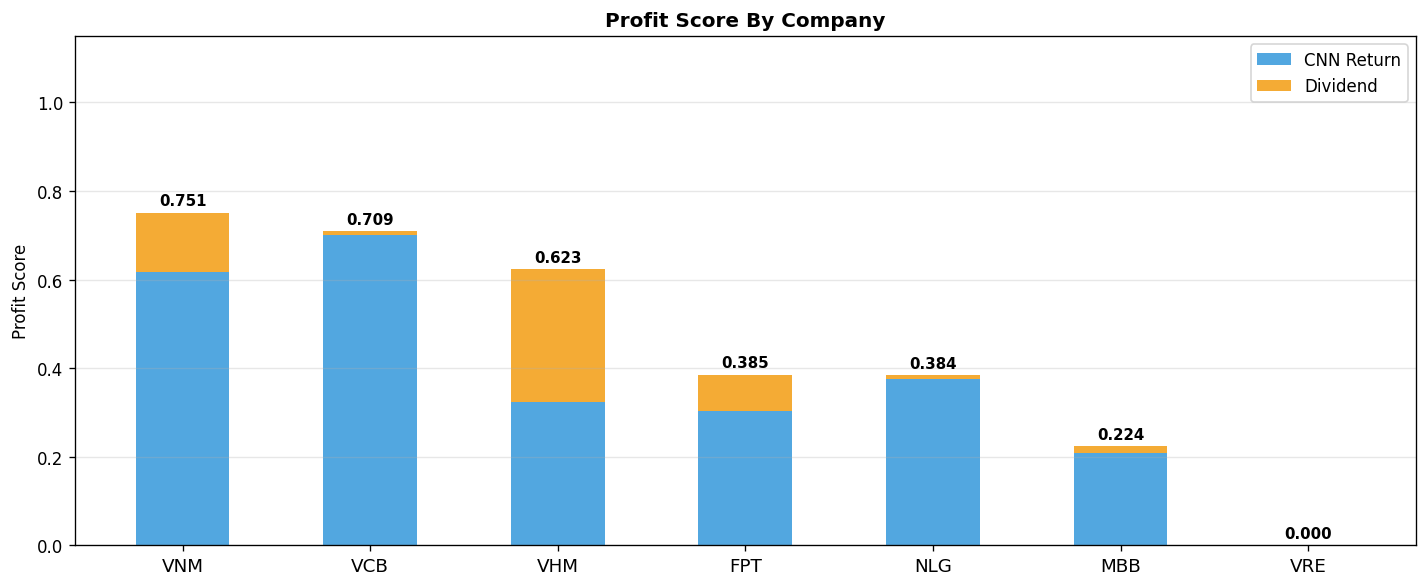

In [110]:
# Profit Score chart
tickers_sorted  = profit_df['Ticker'].tolist()
cnn_contrib  = [W_CNN * cnn_norm[TICKERS.index(t)] for t in tickers_sorted]
div_contrib  = [W_DIV * div_norm[TICKERS.index(t)] for t in tickers_sorted]
total_scores = [profit_scores[TICKERS.index(t)] for t in tickers_sorted]

x  = np.arange(len(tickers_sorted))
bw = 0.5

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
bars1 = ax.bar(x, cnn_contrib, bw, label='CNN Return',
               color='#3498db', alpha=0.85)
bars2 = ax.bar(x, div_contrib, bw, bottom=cnn_contrib,
               label='Dividend', color='#f39c12', alpha=0.85)

for i, (xi, s) in enumerate(zip(x, total_scores)):
    ax.text(xi, s + 0.01, f'{s:.3f}', ha='center',
            va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tickers_sorted, fontsize=11)
ax.set_ylabel('Profit Score')
ax.set_title('Profit Score By Company',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

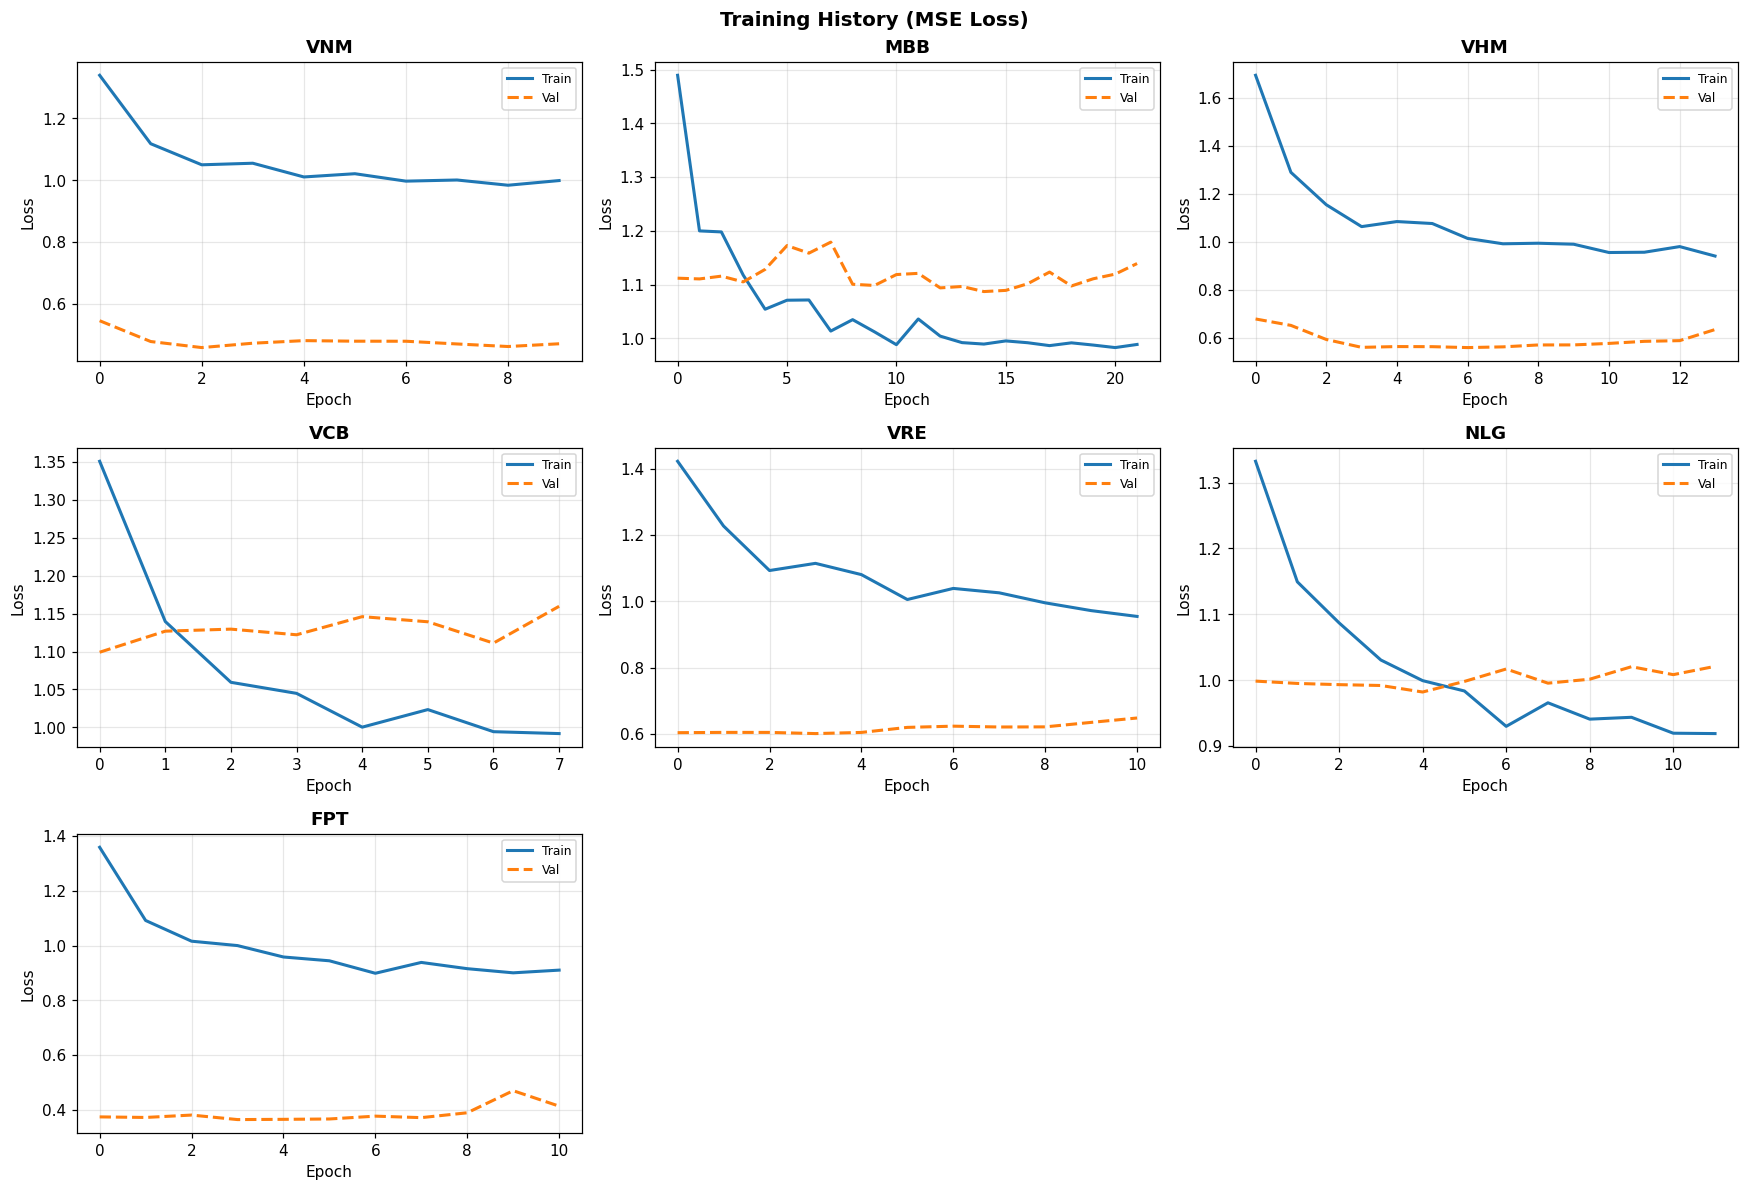

In [111]:
# Training history
fig, axes = plt.subplots(3, 3, figsize=(16, 11), dpi=110)
axes = axes.flatten()

for i, t in enumerate(TICKERS):
    hist = cnn_results[t]['history']
    axes[i].plot(hist.history['loss'], label='Train', lw=2)
    axes[i].plot(hist.history['val_loss'], label='Val',   lw=2, ls='--')
    axes[i].set_title(f'{t}', fontweight='bold')
    axes[i].set_xlabel('Epoch'); axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)

for j in range(len(TICKERS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training History (MSE Loss)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [112]:
# 4.1 Summary
print('Top companies by Profit Score:')
print()
for _, row in profit_df.iterrows():
    print(f"{row['Ticker']:4s}  {row['Profit Score']:.4f}")
profitable_tickers = include
print(f'\n→ Top 4 Profitable Companies = {profitable_tickers}')

Top companies by Profit Score:

VNM   0.7510
VCB   0.7091
VHM   0.6228
FPT   0.3849
NLG   0.3836
MBB   0.2242
VRE   0.0000

→ Top 4 Profitable Companies = ['VNM', 'NLG', 'MBB', 'VHM']


**4.2**

Risk Score = 50% Price Risk + 50% Fundamental Risk
- **Price Risk**: Measures market price volatility and potential loss.
- **Fundamental Risk**: Evaluate companies using sector approach.

In [113]:
# Banking sector
BANKING = {'MBB', 'VCB'}

def load_industry(ticker):
    df = pd.read_csv(f'{ticker}-VNINDEX-Industry.csv')
    df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)],
            inplace=True, errors='ignore')
    row = df[df['ticker'] == ticker]
    if len(row) == 0:
        return None
    return row.iloc[0]

industry_data = {t: load_industry(t) for t in TICKERS}

for t in TICKERS:
    row    = industry_data[t]
    sector = 'Banking' if t in BANKING else 'Non-banking'
    print(f'{t:4s} [{sector:11s}]: '
          f'ROE={row["roe"]:.3f}  ' # Return on Equity
          f'ROA={row["roa"]:.3f}  ' # Return on Assets
          f'DE={row["debtOnEquity"]:.1f}') # Debt on Equity

VNM  [Non-banking]: ROE=0.271  ROA=0.167  DE=0.2
MBB  [Banking    ]: ROE=0.258  ROA=0.026  DE=8.2
VHM  [Non-banking]: ROE=0.210  ROA=0.097  DE=0.2
VCB  [Banking    ]: ROE=0.240  ROA=0.019  DE=12.1
VRE  [Non-banking]: ROE=0.086  ROA=0.068  DE=0.1
NLG  [Non-banking]: ROE=0.062  ROA=0.022  DE=0.4
FPT  [Non-banking]: ROE=0.272  ROA=0.101  DE=0.5


In [114]:
# Using volatility, max drawdown, and value at risk (var) for price risk
def compute_price_risk(ticker, df):
    close   = df['Close'].values
    returns = pd.Series(close).pct_change().dropna().values

    # Volatility
    vol = float(np.std(returns) * np.sqrt(252))

    # Max Drawdown
    peak = np.maximum.accumulate(close)
    dd   = (close - peak) / (peak + 1e-8)
    mdd  = float(abs(np.min(dd)))

    # Var
    var95 = float(abs(np.percentile(returns, 5)))

    return {'volatility': vol, 'max_drawdown': mdd, 'var_95': var95}


price_risks = {t: compute_price_risk(t, history_data[t]) for t in TICKERS}

print('Price-based Risk Factors')
print(f'{"Company":6s} {"Volatility":>12s} {"Max Drawdown":>14s} {"VaR 95%":>10s}')
print('-' * 48)
for t in TICKERS:
    r = price_risks[t]
    print(f'{t:6s} {r["volatility"]:>12.4f} {r["max_drawdown"]:>14.4f} {r["var_95"]:>10.4f}')

Price-based Risk Factors
Company   Volatility   Max Drawdown    VaR 95%
------------------------------------------------
VNM          0.2929         0.6701     0.0290
MBB          0.2929         0.5139     0.0273
VHM          0.3209         0.5375     0.0322
VCB          0.3134         0.5227     0.0300
VRE          0.3910         0.6340     0.0423
NLG          0.3507         0.7259     0.0336
FPT          0.3141         0.8893     0.0350


In [115]:
def compute_fundamental_risk(ticker, row):
    """
    Banking:
      - profitability_risk: High risk if interest margin is low
      - leverage_risk: High risk if bad debt percentage is high
      - efficiency_risk: High risk if ROA is low
    Non-banking:
      - profitability_risk: High risk if profit margin is low
      - leverage_risk: High risk if leverage (debt-to-equity) is high
      - efficiency_risk: High risk if ROE is low
    """
    if ticker in BANKING:
        interest_margin = row['interestMargin'] if pd.notna(row['interestMargin']) else 0.03
        bad_debt        = row['badDebtPercentage'] if pd.notna(row['badDebtPercentage']) else 0.02
        roa             = row['roa'] if pd.notna(row['roa']) else 0.0

        profitability_risk = max(0, 1 - interest_margin * 10)
        leverage_risk      = min(1, bad_debt * 50)
        efficiency_risk    = max(0, 1 - roa * 20)
    else:
        gross_margin = row['grossProfitMargin'] if pd.notna(row['grossProfitMargin']) else 0.2
        debt_equity  = row['debtOnEquity']      if pd.notna(row['debtOnEquity'])      else 1.0
        roe          = row['roe']               if pd.notna(row['roe'])               else 0.0

        profitability_risk = max(0, 1 - gross_margin)
        leverage_risk      = min(1, debt_equity / 3.0)
        efficiency_risk    = max(0, 1 - roe)

    return {
        'profitability_risk': profitability_risk,
        'leverage_risk'     : leverage_risk,
        'efficiency_risk'   : efficiency_risk,
    }


fund_risks = {t: compute_fundamental_risk(t, industry_data[t]) for t in TICKERS}

print('Sector Fundamental Risk Factors')
print(f'{"Company":6s} {"Sector":12s} {"Profitability":>14s} {"Leverage":>10s} {"Efficiency":>12s}')
print('-' * 58)
for t in TICKERS:
    r      = fund_risks[t]
    sector = 'Banking' if t in BANKING else 'Non-banking'
    print(f'{t:6s} {sector:12s} '
          f'{r["profitability_risk"]:>14.4f} '
          f'{r["leverage_risk"]:>10.4f} '
          f'{r["efficiency_risk"]:>12.4f}')

Sector Fundamental Risk Factors
Company Sector        Profitability   Leverage   Efficiency
----------------------------------------------------------
VNM    Non-banking          0.6120     0.0667       0.7290
MBB    Banking              0.4300     0.5500       0.4800
VHM    Non-banking          0.5160     0.0667       0.7900
VCB    Banking              0.6600     0.3500       0.6200
VRE    Non-banking          0.4950     0.0333       0.9140
NLG    Non-banking          0.5000     0.1333       0.9380
FPT    Non-banking          0.5980     0.1667       0.7280


In [116]:
# Weights
# Price Risk
W_VOL  = 0.35   # volatility
W_MDD  = 0.35   # max drawdown
W_VAR  = 0.30   # VaR 95%

# Fundamental Risk
W_PROF = 0.40   # profitability risk
W_LEV  = 0.35   # leverage risk
W_EFF  = 0.25   # efficiency risk

W_PRICE = 0.50  # price weight
W_FUND  = 0.50  # fundamental weight

def normalize_across(values_dict, key, invert=False):
    vals = np.array([values_dict[t][key] for t in TICKERS], dtype=float)
    mn, mx = vals.min(), vals.max()
    norm = (vals - mn) / (mx - mn + 1e-8)
    if invert:
        norm = 1 - norm
    return dict(zip(TICKERS, norm))

# Normalize price-based metrics
vol_n  = normalize_across(price_risks, 'volatility')
mdd_n  = normalize_across(price_risks, 'max_drawdown')
var_n  = normalize_across(price_risks, 'var_95')

# Re-normalize across companies for fair comparison
prof_n = normalize_across(fund_risks, 'profitability_risk')
lev_n  = normalize_across(fund_risks, 'leverage_risk')
eff_n  = normalize_across(fund_risks, 'efficiency_risk')

# Compute final Risk Score
risk_scores = {}
for t in TICKERS:
    price_score = (W_VOL  * vol_n[t] +
                   W_MDD  * mdd_n[t] +
                   W_VAR  * var_n[t])
    fund_score  = (W_PROF * prof_n[t] +
                   W_LEV  * lev_n[t]  +
                   W_EFF  * eff_n[t])
    risk_scores[t] = {
        'price_risk'  : round(price_score, 4),
        'fund_risk'   : round(fund_score,  4),
        'risk_score'  : round(W_PRICE * price_score + W_FUND * fund_score, 4),
        'volatility'  : round(price_risks[t]['volatility'], 4),
        'max_drawdown': round(price_risks[t]['max_drawdown'], 4),
        'var_95'      : round(price_risks[t]['var_95'], 4),
        'prof_risk'   : round(fund_risks[t]['profitability_risk'], 4),
        'lev_risk'    : round(fund_risks[t]['leverage_risk'], 4),
        'eff_risk'    : round(fund_risks[t]['efficiency_risk'], 4),
        'sector'      : 'Banking' if t in BANKING else 'Non-banking',
    }

# Summary table
RISK_THRESHOLD = 0.55  # Risk Score > 0.55 → eliminate from Prudent portfolio

risk_df = pd.DataFrame(risk_scores).T
risk_df = risk_df.sort_values('risk_score', ascending=False)

print('Risk Score Ranking')
print(f'Risk Score > {RISK_THRESHOLD} → High Risk → exclude from Prudent Portfolio')
print('-' * 80)
display_cols = ['sector', 'risk_score', 'price_risk', 'fund_risk',
                'volatility', 'max_drawdown', 'var_95']
print(risk_df[display_cols].to_string())

Risk Score Ranking
Risk Score > 0.55 → High Risk → exclude from Prudent Portfolio
--------------------------------------------------------------------------------
          sector risk_score price_risk fund_risk volatility max_drawdown  var_95
VRE  Non-banking      0.556      0.762    0.3499      0.391        0.634  0.0423
FPT  Non-banking     0.5488     0.5797    0.5179     0.3141       0.8893   0.035
NLG  Non-banking     0.4849     0.5303    0.4395     0.3507       0.7259  0.0336
VCB      Banking     0.4129     0.1349    0.6909     0.3134       0.5227    0.03
VNM  Non-banking     0.3271     0.1792     0.475     0.2929       0.6701   0.029
VHM  Non-banking     0.2806     0.2198    0.3414     0.3209       0.5375  0.0322
MBB      Banking      0.175        0.0      0.35     0.2929       0.5139  0.0273


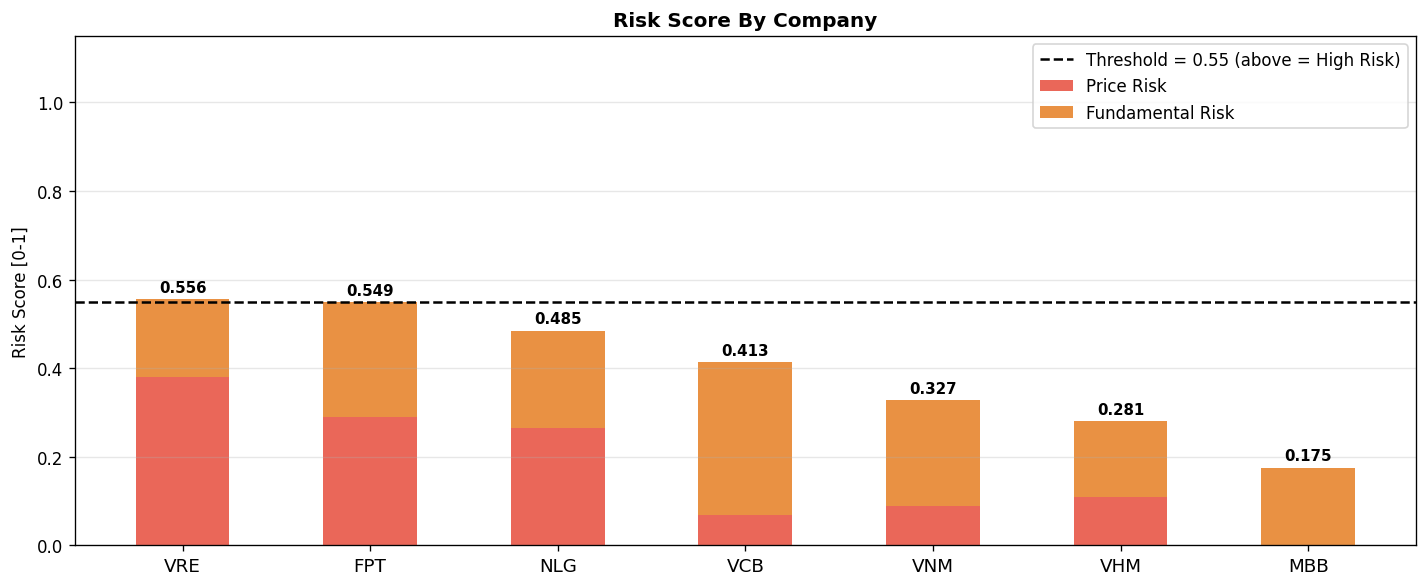

In [117]:
# Risk Score chart
tickers_sorted = risk_df.index.tolist()
price_scores_s = [risk_scores[t]['price_risk'] * W_PRICE for t in tickers_sorted]
fund_scores_s  = [risk_scores[t]['fund_risk']  * W_FUND  for t in tickers_sorted]
total_risk_s   = [risk_scores[t]['risk_score']            for t in tickers_sorted]

x  = np.arange(len(tickers_sorted))
bw = 0.5

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
ax.bar(x, price_scores_s, bw, label='Price Risk',
       color='#e74c3c', alpha=0.85)
ax.bar(x, fund_scores_s,  bw, bottom=price_scores_s,
       label='Fundamental Risk', color='#e67e22', alpha=0.85)

for i, (xi, s) in enumerate(zip(x, total_risk_s)):
    ax.text(xi, float(s) + 0.01, f'{float(s):.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(RISK_THRESHOLD, color='black', lw=1.5, ls='--',
           label=f'Threshold = {RISK_THRESHOLD} (above = High Risk)')
ax.set_xticks(x)
ax.set_xticklabels(tickers_sorted, fontsize=11)
ax.set_ylabel('Risk Score [0-1]')
ax.set_ylim(0, 1.15)
ax.set_title('Risk Score By Company',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
# 4.2 Summary
high_risk = [t for t in TICKERS
             if risk_scores[t]['risk_score'] > RISK_THRESHOLD]
low_risk  = [t for t in TICKERS
             if risk_scores[t]['risk_score'] <= RISK_THRESHOLD]

print(f'Risk Score = {W_PRICE:.0%} Price-based + {W_FUND:.0%} Fundamental')
print(f'Threshold  = {RISK_THRESHOLD}')
print()
print('Risk score ranking:')
for t in tickers_sorted:
    r = risk_scores[t]
    print(f'{t:4s} [{r["sector"]:11s}]  '
          f'{r["risk_score"]:.4f}')
high_risk_tickers = high_risk
low_risk_tickers  = low_risk
print(f'\nHigh risk company = {high_risk_tickers}')
print(f'Low risk companies  = {low_risk_tickers}')

Risk Score = 50% Price-based + 50% Fundamental
Threshold  = 0.55

Risk score ranking:
VRE  [Non-banking]  0.5560
FPT  [Non-banking]  0.5488
NLG  [Non-banking]  0.4849
VCB  [Banking    ]  0.4129
VNM  [Non-banking]  0.3271
VHM  [Non-banking]  0.2806
MBB  [Banking    ]  0.1750

High risk company = ['VRE']
Low risk companies  = ['VNM', 'MBB', 'VHM', 'VCB', 'NLG', 'FPT']


**4.3**

Two type of portfolio:
- **Risk-taking**: Based on Profit Score to maximize expected return.
- **Prudent**: Based on Profit Score & Low Risk Score to maximize sharpe ratio.

In [119]:
def build_return_matrix(tickers, history_data, window=500):
    ret_dict = {}
    for t in tickers:
        close = history_data[t]['Close'].values
        r     = pd.Series(close).pct_change().dropna().values
        ret_dict[t] = r[-window:] if len(r) >= window else r

    min_len = min(len(v) for v in ret_dict.values())
    mat = np.array([ret_dict[t][-min_len:] for t in tickers]).T
    return pd.DataFrame(mat, columns=tickers)

# Annualized stats
def portfolio_stats(weights, mu, cov, rf=0.0):
    ret = float(weights @ mu)
    vol = float(np.sqrt(weights @ cov @ weights))
    sharpe = (ret - rf) / (vol + 1e-8)
    return ret, vol, sharpe

# Show return matrix overview
ret_all = build_return_matrix(TICKERS, history_data)
mu_all  = ret_all.mean() * 252
cov_all = ret_all.cov()  * 252

print('Annualized Expected Return & Volatility')
print('-' * 34)
print(f'{"Company":6s} {"Exp Return":>12s} {"Volatility":>12s}')
print('-' * 34)
for t in TICKERS:
    vol_t = float(np.sqrt(cov_all.loc[t, t]))
    print(f'{t:6s} {mu_all[t]:>11.2%} {vol_t:>11.2%}')

Annualized Expected Return & Volatility
----------------------------------
Company   Exp Return   Volatility
----------------------------------
VNM         -8.72%      24.08%
MBB          7.40%      36.98%
VHM        -24.86%      31.20%
VCB         14.33%      27.97%
VRE         -2.81%      40.42%
NLG          1.61%      48.00%
FPT         25.30%      29.02%


In [120]:
def markowitz_optimize(tickers, history_data,
                       mode='sharpe',
                       w_min=0.05, w_max=0.50,
                       rf=0.0, window=500):
    """
    Markowitz Mean-Variance Optimization.
    mode='sharpe' : maximize Sharpe ratio → Prudent
    mode='return' : maximize expected return → Risk-taking
    """
    ret_df = build_return_matrix(tickers, history_data, window)
    mu     = ret_df.mean().values * 252
    cov    = ret_df.cov().values  * 252
    n      = len(tickers)
    w0     = np.ones(n) / n

    if mode == 'sharpe':
        def objective(w):
            r = w @ mu
            v = np.sqrt(w @ cov @ w)
            return -(r - rf) / (v + 1e-8)
    else:  # return
        def objective(w):
            return -(w @ mu)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(w_min, w_max)] * n

    result = minimize(objective, w0,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-12})

    w   = result.x
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ cov @ w))
    sr  = (ret - rf) / (vol + 1e-8)
    return w, ret, vol, sr, mu, cov

In [121]:
# Define portfolio
rt_universe = profitable_tickers
pr_universe = [t for t in profitable_tickers if t in low_risk_tickers]

# Fallback: if prudent < 2 then take top profitable from low risk
if len(pr_universe) < 2:
    pr_universe = sorted(
        low_risk_tickers,
        key=lambda t: profit_scores[TICKERS.index(t)],
        reverse=True
    )[:max(2, len(low_risk_tickers))]

print(f'Risk-taking companies: {rt_universe}')
print(f'Prudent companies: {pr_universe}')

# Optimize
print('\nRunning Risk-taking portfolio...')
w_rt, ret_rt, vol_rt, sr_rt, mu_rt, cov_rt = markowitz_optimize(
    rt_universe, history_data,
    mode='return', w_min=0.05, w_max=0.50)

print('Running Prudent portfolio...')
w_pr, ret_pr, vol_pr, sr_pr, mu_pr, cov_pr = markowitz_optimize(
    pr_universe, history_data,
    mode='sharpe', w_min=0.05, w_max=0.40)

# Portfolio tables
def make_port_df(tickers, weights, profit_scores_arr,
                 risk_scores_dict, ticker_list):
    return pd.DataFrame({
        'Company'      : tickers,
        'Weight (%)'  : np.round(weights * 100, 2),
        'Profit Score': [round(profit_scores_arr[ticker_list.index(t)], 4)
                         for t in tickers],
        'Risk Score'  : [round(risk_scores_dict[t]['risk_score'], 4)
                         for t in tickers],
        'Sector'      : [risk_scores_dict[t]['sector'] for t in tickers],
    }).sort_values('Weight (%)', ascending=False).reset_index(drop=True)


port_rt_df = make_port_df(rt_universe, w_rt, profit_scores, risk_scores, TICKERS)
port_pr_df = make_port_df(pr_universe, w_pr, profit_scores, risk_scores, TICKERS)
print()
print('RISK-TAKING PORTFOLIO')
print('-'*60)
print(port_rt_df.to_string(index=False))
print(f'\n  Expected Return : {ret_rt:.2%}')
print(f'  Volatility      : {vol_rt:.2%}')
print(f'  Sharpe Ratio    : {sr_rt:.3f}')
print()
print('PRUDENT PORTFOLIO')
print('-'*60)
print(port_pr_df.to_string(index=False))
print(f'\n  Expected Return : {ret_pr:.2%}')
print(f'  Volatility      : {vol_pr:.2%}')
print(f'  Sharpe Ratio    : {sr_pr:.3f}')

Risk-taking companies: ['VNM', 'NLG', 'MBB', 'VHM']
Prudent companies: ['VNM', 'NLG', 'MBB', 'VHM']

Running Risk-taking portfolio...
Running Prudent portfolio...

RISK-TAKING PORTFOLIO
------------------------------------------------------------
Company  Weight (%)  Profit Score  Risk Score      Sector
    MBB        50.0        0.2242      0.1750     Banking
    NLG        40.0        0.3836      0.4849 Non-banking
    VNM         5.0        0.7510      0.3271 Non-banking
    VHM         5.0        0.6228      0.2806 Non-banking

  Expected Return : 2.66%
  Volatility      : 33.62%
  Sharpe Ratio    : 0.079

PRUDENT PORTFOLIO
------------------------------------------------------------
Company  Weight (%)  Profit Score  Risk Score      Sector
    NLG        40.0        0.3836      0.4849 Non-banking
    MBB        40.0        0.2242      0.1750     Banking
    VNM        15.0        0.7510      0.3271 Non-banking
    VHM         5.0        0.6228      0.2806 Non-banking

  Expected R

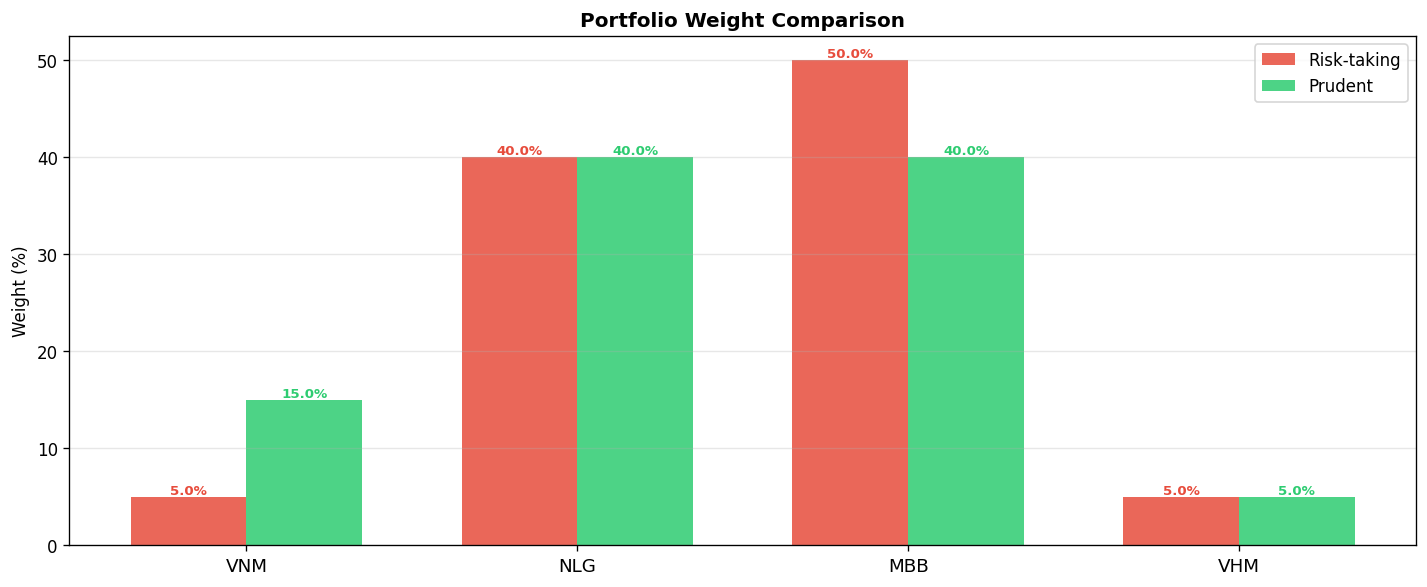

In [122]:
# Weight comparison chart
all_tickers_union = list(dict.fromkeys(rt_universe + pr_universe))

rt_w_map = dict(zip(rt_universe, w_rt * 100))
pr_w_map = dict(zip(pr_universe, w_pr * 100))

rt_bars = [rt_w_map.get(t, 0) for t in all_tickers_union]
pr_bars = [pr_w_map.get(t, 0) for t in all_tickers_union]

x  = np.arange(len(all_tickers_union))
bw = 0.35

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
ax.bar(x - bw/2, rt_bars, bw, label='Risk-taking',
       color='#e74c3c', alpha=0.85)
ax.bar(x + bw/2, pr_bars, bw, label='Prudent',
       color='#2ecc71', alpha=0.85)

for i, (r, p) in enumerate(zip(rt_bars, pr_bars)):
    if r > 0:
        ax.text(i - bw/2, r + 0.3, f'{r:.1f}%',
                ha='center', fontsize=8, color='#e74c3c', fontweight='bold')
    if p > 0:
        ax.text(i + bw/2, p + 0.3, f'{p:.1f}%',
                ha='center', fontsize=8, color='#2ecc71', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_tickers_union, fontsize=11)
ax.set_ylabel('Weight (%)')
ax.set_title('Portfolio Weight Comparison',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

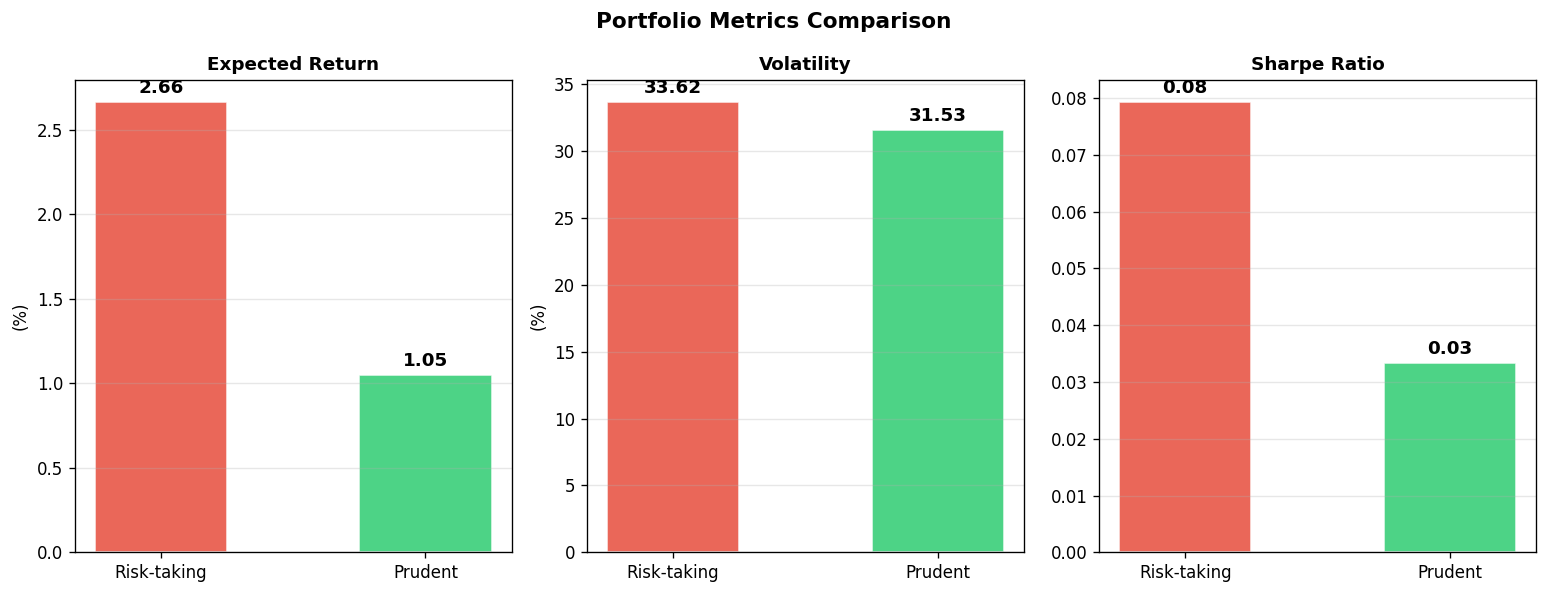

In [123]:
# Metrics comparison plot
fig, axes = plt.subplots(1, 3, figsize=(13, 5), dpi=120)

metrics  = ['Expected Return', 'Volatility', 'Sharpe Ratio']
rt_vals  = [ret_rt * 100, vol_rt * 100, sr_rt]
pr_vals  = [ret_pr * 100, vol_pr * 100, sr_pr]
ylabels  = ['(%)', '(%)', '']

for ax, metric, rv, pv, ylabel in zip(axes, metrics, rt_vals, pr_vals, ylabels):
    bars = ax.bar(['Risk-taking', 'Prudent'], [rv, pv],
                  color=['#e74c3c', '#2ecc71'], alpha=0.85,
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, [rv, pv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(abs(rv), abs(pv)) * 0.02,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Portfolio Metrics Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()